# Ejemplos y Visualización del Mercado

El objetivo de este notebook es mostrar los ejemplos resultantes del modelo ganador y además de ello mostrar una visualización mediante un mapa de la Comunidad de Madrid.


In [43]:
# Importar librerías
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from google.colab import drive
import pickle
from sklearn.model_selection import train_test_split

In [44]:
# Importaciones Generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Embedding, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Keras Tuner
!pip install -q keras-tuner

import keras_tuner as kt

In [45]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/TFM/ENTREGA/'

# --- Cargar el modelo y los objetos de preprocesamiento ---
loaded_model = load_model(f'{file_path}/modelo_con_embeddings.h5')

with open(f'{file_path}/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

with open(f'{file_path}/label_encoders.pkl', 'rb') as f:
    loaded_le_dict = pickle.load(f)

print("Modelo y preprocesadores cargados correctamente.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Modelo y preprocesadores cargados correctamente.


In [56]:

#Dataset
#Carpeta de ficheros_csv del drive
drive.mount('/content/drive')


df_modelado = pd.read_csv('/content/drive/MyDrive/TFM/Ficheros CSV/df_limpios_con_vd_V_final.csv')

df_mapa = df_modelado.copy()

# Definir las variables
y = df_modelado['deal_score']
cols_to_drop = [
    'deal_score', 'price', 'priceByArea', 'price_per_room',
    'priceInfo.price.priceDropInfo.priceDropPercentage',
    'priceInfo.price.priceDropInfo.priceDropValue',
    'latitude', 'longitude'
]
X = df_modelado.drop(columns=cols_to_drop)
numeric_features = X.select_dtypes(include=np.number).columns.drop('zona_cluster').tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist() + ['zona_cluster']

# Asegurar que los tipos de datos son consistentes
for col in categorical_features:
    X[col] = X[col].astype(str)

# Dividir los datos
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# Preprocesar X_test con los objetos cargados
X_test_processed = X_test.copy()

for col in categorical_features:
    le = loaded_le_dict[col]
    X_test_processed[col] = X_test_processed[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

X_test_num_scaled = loaded_scaler.transform(X_test_processed[numeric_features])

# Preparar las entradas para el modelo
X_test_inputs = [X_test_processed[col].values for col in categorical_features] + [X_test_num_scaled]

# Realizar las predicciones
y_pred_emb = loaded_model.predict(X_test_inputs)

# Convertir las predicciones a un DataFrame o Series
y_pred = pd.Series(y_pred_emb.flatten(), index=y_test.index)

165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [48]:
# Combinar datos reales y predichos en un solo DataFrame
results_df = pd.DataFrame({
    'deal_score_real': y_test,
    'deal_score_predicho': y_pred
})

# Calcular la diferencia entre el deal_score real y el predicho
# Un valor negativo grande indica que el modelo predice un score mucho menor que el real,
# lo que sugiere que la propiedad está sobrevalorada.
# Un valor positivo grande indica que el modelo predice un score mucho mayor que el real,
# lo que sugiere que la propiedad está infravalorada.
results_df['diferencia'] = results_df['deal_score_predicho'] - results_df['deal_score_real']

# Ordenar por la diferencia para encontrar los casos de infravaloración (mayores diferencias positivas)
propiedades_infravaloradas = results_df.sort_values(by='diferencia', ascending=False)

# Obtener los 3 primeros ejemplos (los más infravalorados según el modelo)
top_3_infravalorados = propiedades_infravaloradas.head()

# Obtener los atributos clave de los ejemplos
atributos_clave = df_modelado.loc[top_3_infravalorados.index, ['zona_cluster', 'rooms', 'size', 'price']]
ejemplos_finales = pd.concat([atributos_clave, top_3_infravalorados], axis=1)

# Imprimir la tabla final
print(ejemplos_finales)

# O si prefieres una representación más limpia:
from IPython.display import display
display(ejemplos_finales)

       zona_cluster  rooms   size     price  deal_score_real  \
25443            12      4  158.0  358000.0        -0.998879   
17122            41      2   45.0   19000.0        -0.525309   
9495              8      1   47.0  187000.0        -0.091760   
16810            19      2   51.0  130000.0        -0.268160   
10580            42      2   80.0  199800.0        -0.391622   

       deal_score_predicho  diferencia  
25443             0.149055    1.147934  
17122             0.551762    1.077072  
9495              0.850339    0.942098  
16810             0.664705    0.932865  
10580             0.523553    0.915175  


,zona_cluster,rooms,size,price,deal_score_real,deal_score_predicho,diferencia
25443,12,4,158.0,358000.0,-0.998879,0.149055,1.147934
17122,41,2,45.0,19000.0,-0.525309,0.551762,1.077072
9495,8,1,47.0,187000.0,-0.091760,0.850339,0.942098
16810,19,2,51.0,130000.0,-0.268160,0.664705,0.932865
10580,42,2,80.0,199800.0,-0.391622,0.523553,0.915175


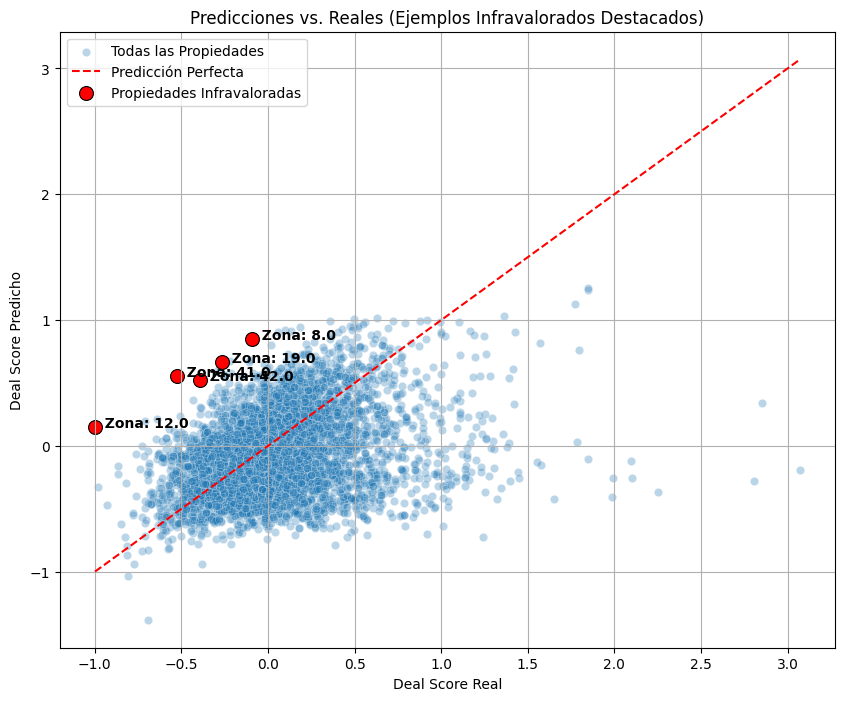

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que 'ejemplos_finales' es el DataFrame que creaste
# con las propiedades infravaloradas.

plt.figure(figsize=(10, 8))
# Trazar todos los puntos de test
sns.scatterplot(x=y_test.values, y=y_pred_emb.flatten(), alpha=0.3, label='Todas las Propiedades')

# Trazar la línea de predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         linestyle='--', color='red', label='Predicción Perfecta')

# Resaltar los 3 ejemplos infravalorados
sns.scatterplot(
    x=ejemplos_finales['deal_score_real'],
    y=ejemplos_finales['deal_score_predicho'],
    color='red',
    s=100,  # Aumenta el tamaño del marcador
    edgecolor='black',
    label='Propiedades Infravaloradas'
)

# Añadir etiquetas a los puntos destacados para mayor claridad
for i, row in ejemplos_finales.iterrows():
    plt.text(row['deal_score_real'], row['deal_score_predicho'], f"  Zona: {row['zona_cluster']}",
             horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title('Predicciones vs. Reales (Ejemplos Infravalorados Destacados)')
plt.xlabel('Deal Score Real')
plt.ylabel('Deal Score Predicho')
plt.legend()
plt.grid(True)
plt.show()

In [50]:
# Assuming 'ejemplos_finales' is the DataFrame with the infravalued properties
# Get the original index to find the coordinates
indices = ejemplos_finales.index

# Get the original latitude and longitude from the full dataset
ubicaciones = df_modelado.loc[indices, ['latitude', 'longitude', 'zona_cluster']]

# Combine the location data with your analysis results
ejemplos_finales_map = pd.concat([ejemplos_finales, ubicaciones], axis=1)

In [51]:
!pip install folium

In [52]:
ejemplos_finales.columns

Index(['zona_cluster', 'rooms', 'size', 'price', 'deal_score_real',
       'deal_score_predicho', 'diferencia'],
      dtype='object')

In [53]:
# Filter df_mapa to include only the zona_cluster values present in ejemplos_finales_map
df_map_filtered = df_mapa[df_mapa["zona_cluster"].isin(ejemplos_finales_map['zona_cluster'].iloc[:, 0])]
df_map_filtered = df_map_filtered[['zona_cluster', 'rooms', 'size', 'price', 'latitude', 'longitude']]
# # Select only the columns present in ejemplos_finales - This caused an error and is removed
# df_map_filtered = df_map_filtered[ejemplos_finales.columns]

In [54]:
df_map_filtered = df_map_filtered[['zona_cluster', 'rooms', 'size', 'price', 'latitude', 'longitude']]

In [55]:
import folium
from folium.plugins import MarkerCluster

# Get the average location to center the map using the original df_mapa
center_lat = df_mapa['latitude'].mean()
center_lon = df_mapa['longitude'].mean()

# Create a map centered around the average location of all properties
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Create a MarkerCluster for df_map_filtered points
marker_cluster_filtered = MarkerCluster(name='Filtered Properties').add_to(m)

# Add markers for df_map_filtered
for idx, row in df_map_filtered.iterrows():
    # Create a simple tooltip with price and size
    tooltip_text = f"Price: {row.get('price', 'N/A')}<br>Size: {row.get('size', 'N/A')}" # Use .get to handle potential missing columns gracefully
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.4,
        tooltip=tooltip_text
    ).add_to(marker_cluster_filtered)

# Create a MarkerCluster for ejemplos_finales_map points (undervalued)
marker_cluster_undervalued = MarkerCluster(name='Undervalued Properties').add_to(m)

# Add markers for ejemplos_finales_map
for idx, row in ejemplos_finales_map.iterrows():
    # Create a simple tooltip with price and size
    tooltip_text = f"Price: {row.get('price', 'N/A')}<br>Size: {row.get('size', 'N/A')}" # Use .get to handle potential missing columns gracefully
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        icon=folium.Icon(color='red', icon='star'), # Using a star icon to highlight
        tooltip=tooltip_text
    ).add_to(marker_cluster_undervalued)

# Add layer control to toggle layers
folium.LayerControl().add_to(m)

# Display the map
m

Output hidden; open in https://colab.research.google.com to view.

In [59]:
# Get the index of the undervalued properties from ejemplos_finales
undervalued_indices = ejemplos_finales.index

# Filter the original dataframe (df_modelado) using these indices
full_undervalued_info = df_modelado.loc[undervalued_indices]

print("Full information for the top undervalued properties:")
display(full_undervalued_info)

Full information for the top undervalued properties:


,bathrooms,detailedType.subTypology,detailedType.typology,district,exterior,floor,has360,has3DTour,hasLift,hasPlan,...,padel,zonas_comunes,parque,score_final,distancia_al_centro,price_per_room,size_per_room,amenities_score,zona_cluster,deal_score
25443,2,Vacío,flat,Sureste,1,2.0,0,0,1,1,...,0,0,0,15,28.676455,89500.0,39.5,19,12,-0.998879
17122,1,Vacío,flat,031-01,1,0.0,0,0,0,0,...,0,0,0,6,83.571596,9500.0,22.5,7,41,-0.525309
9495,1,studio,flat,Praderón,1,0.0,0,0,1,1,...,0,0,0,15,17.698712,187000.0,47.0,20,8,-0.091760
16810,1,Vacío,flat,Carabanchel,1,4.0,0,0,1,0,...,0,0,0,6,3.070593,65000.0,25.5,8,19,-0.268160
10580,1,Vacío,flat,Casco Antiguo,1,4.0,1,0,1,1,...,0,1,0,9,19.165811,99900.0,40.0,15,42,-0.391622


In [61]:
# Get the sizes of the properties in ejemplos_finales
ejemplos_sizes = ejemplos_finales['size']

# Calculate the minimum and maximum size for filtering
min_size = ejemplos_sizes.min() - 20
max_size = ejemplos_sizes.max() + 20

# Ensure sizes are not negative
min_size = max(0, min_size)

# Filter df_map_filtered by size
size_filtered_map_data = df_map_filtered[(df_map_filtered['size'] >= min_size) & (df_map_filtered['size'] <= max_size)]

print(f"Filtered data by size range ({min_size} - {max_size}):")
display(size_filtered_map_data.head())
display(size_filtered_map_data.shape)

Filtered data by size range (25.0 - 178.0):


,zona_cluster,rooms,size,price,latitude,longitude
9,8,5,158.0,2073199.0,40.514470,-3.634451
55,8,5,158.0,2252550.0,40.528412,-3.608031
90,8,5,158.0,2140199.0,40.518050,-3.616864
150,8,4,158.0,2136699.0,40.516477,-3.612833
213,8,3,161.0,1245000.0,40.505289,-3.608395


(2375, 6)

In [79]:
import folium
from folium.plugins import MarkerCluster

def create_comparison_map(df_all_properties, df_highlighted_properties, center_lat=40.416775, center_lon=-3.703790): # Default to Madrid center coordinates
    """
    Creates a Folium map comparing all properties in an area with highlighted properties.

    Args:
        df_all_properties (pd.DataFrame): DataFrame containing all properties to display.
                                         Must include 'latitude', 'longitude', 'price', 'size'.
        df_highlighted_properties (pd.DataFrame): DataFrame containing properties to highlight.
                                                 Must include 'latitude', 'longitude', 'price', 'size'.
        center_lat (float, optional): Latitude for centering the map. Defaults to Madrid center.
        center_lon (float, optional): Longitude for centering the map. Defaults to Madrid center.

    Returns:
        folium.Map: The generated Folium map object.
    """
    # Create a map centered around the specified location
    m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

    # Create a MarkerCluster for all properties points
    marker_cluster_all = MarkerCluster(name='All Properties').add_to(m)

    # Add markers for all properties
    for idx, row in df_all_properties.iterrows():
        # Create a simple tooltip with price and size
        tooltip_text = f"Price: {row.get('price', 'N/A')}<br>Size: {row.get('size', 'N/A')}"
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.4,
            tooltip=tooltip_text
        ).add_to(marker_cluster_all)

    # Create a MarkerCluster for highlighted properties points
    marker_cluster_highlighted = MarkerCluster(name='Highlighted Properties').add_to(m)


    # Add markers for highlighted properties
    for idx, row in df_highlighted_properties.iterrows():
        # Create a simple tooltip with price and size
        tooltip_text = f"Price: {row.get('price', 'N/A')}<br>Size: {row.get('size', 'N/A')}"
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            icon=folium.Icon(color='red', icon='star'), # Using a star icon to highlight
            tooltip=tooltip_text
        ).add_to(marker_cluster_highlighted)

    # Add layer control to toggle layers
    folium.LayerControl().add_to(m)

    return m

In [67]:
center_lat = df_mapa['latitude'].mean()
center_lon = df_mapa['longitude'].mean()

create_comparison_map(size_filtered_map_data, ejemplos_finales_map, center_lat, center_lon)

In [68]:
def get_filtered_undervalued_examples(
    df_data,
    y_real,
    y_pred,
    price_min=None,
    price_max=None,
    size_min=None,
    size_max=None,
    top_n=5 # Default to top 5 as in the original example
):
    """
    Identifies top potentially undervalued properties with optional filtering by price and size.

    Args:
        df_data (pd.DataFrame): The original DataFrame containing property details.
        y_real (pd.Series): The real deal scores for the test set.
        y_pred (pd.Series): The predicted deal scores for the test set.
        price_min (float, optional): Minimum price for filtering. Defaults to None.
        price_max (float, optional): Maximum price for filtering. Defaults to None.
        size_min (float, optional): Minimum size for filtering. Defaults to None.
        size_max (float, optional): Maximum size for filtering. Defaults to None.
        top_n (int, optional): The number of top undervalued properties to return. Defaults to 5.

    Returns:
        pd.DataFrame: A DataFrame containing the top_n undervalued properties
                      that meet the filtering criteria, with key attributes and deal scores.
    """

    # Combine real and predicted deal scores
    results_df = pd.DataFrame({
        'deal_score_real': y_real,
        'deal_score_predicho': y_pred
    })

    # Calculate the difference
    results_df['diferencia'] = results_df['deal_score_predicho'] - results_df['deal_score_real']

    # Merge with original data to get price and size for filtering
    # Ensure the merge is done on the index which corresponds to the original df_data index
    results_with_attributes = results_df.merge(
        df_data[['price', 'size', 'zona_cluster', 'rooms']], # Include other key attributes if needed
        left_index=True,
        right_index=True
    )

    # Apply optional price filtering
    if price_min is not None:
        results_with_attributes = results_with_attributes[results_with_attributes['price'] >= price_min]
    if price_max is not None:
        results_with_attributes = results_with_attributes[results_with_attributes['price'] <= price_max]

    # Apply optional size filtering
    if size_min is not None:
        results_with_attributes = results_with_attributes[results_with_attributes['size'] >= size_min]
    if size_max is not None:
        results_with_attributes = results_with_attributes[results_with_attributes['size'] <= size_max]

    # Sort by the difference to find the most undervalued (largest positive differences)
    propiedades_infravaloradas_filtered = results_with_attributes.sort_values(by='diferencia', ascending=False)

    # Get the top_n examples
    top_n_undervalued = propiedades_infravaloradas_filtered.head(top_n)

    # Return the selected examples with relevant columns
    # The columns from results_with_attributes already include the necessary info
    return top_n_undervalued[['zona_cluster', 'rooms', 'size', 'price', 'deal_score_real', 'deal_score_predicho', 'diferencia']]

In [70]:
# Example usage of the function:
# Get top 5 undervalued properties without any extra filtering
undervalued_examples_default = get_filtered_undervalued_examples(df_modelado, y_test, y_pred)
print("Top 5 Undervalued Properties (Default):")
display(undervalued_examples_default)

# Example usage with price and size filtering:
# Get top 3 undervalued properties between 100k and 300k price and size between 50 and 100
undervalued_examples_filtered = get_filtered_undervalued_examples(
    df_modelado,
    y_test,
    y_pred,
    price_min=100000,
    price_max=300000,
    size_min=50,
    size_max=80,
    top_n=3
)
print("\nTop 3 Undervalued Properties (Filtered by Price and Size):")
display(undervalued_examples_filtered)

Top 5 Undervalued Properties (Default):


,zona_cluster,rooms,size,price,deal_score_real,deal_score_predicho,diferencia
25443,12,4,158.0,358000.0,-0.998879,0.149055,1.147934
17122,41,2,45.0,19000.0,-0.525309,0.551762,1.077072
9495,8,1,47.0,187000.0,-0.091760,0.850339,0.942098
16810,19,2,51.0,130000.0,-0.268160,0.664705,0.932865
10580,42,2,80.0,199800.0,-0.391622,0.523553,0.915175



Top 3 Undervalued Properties (Filtered by Price and Size):


,zona_cluster,rooms,size,price,deal_score_real,deal_score_predicho,diferencia
16810,19,2,51.0,130000.0,-0.268160,0.664705,0.932865
10580,42,2,80.0,199800.0,-0.391622,0.523553,0.915175
24701,42,2,80.0,199800.0,-0.391622,0.523535,0.915157


In [77]:
undervalued_examples_filtered

,zona_cluster,rooms,size,price,deal_score_real,deal_score_predicho,diferencia
16810,19,2,51.0,130000.0,-0.268160,0.664705,0.932865
10580,42,2,80.0,199800.0,-0.391622,0.523553,0.915175
24701,42,2,80.0,199800.0,-0.391622,0.523535,0.915157


In [74]:
# Filter df_mapa to include only the zona_cluster values present in undervalued_examples_filtered
df_map_filtered = df_mapa[df_mapa["zona_cluster"].isin(undervalued_examples_filtered['zona_cluster'])]
df_map_filtered = df_map_filtered[['zona_cluster', 'rooms', 'size', 'price', 'latitude', 'longitude']]
# # Select only the columns present in ejemplos_finales - This caused an error and is removed
# df_map_filtered = df_map_filtered[ejemplos_finales.columns]

In [76]:
# Get the average location to center the map using the original df_mapa
center_lat = df_mapa['latitude'].mean()
center_lon = df_mapa['longitude'].mean()

# Call the create_comparison_map function with the filtered data and undervalued examples with locations
create_comparison_map(df_map_filtered, ejemplos_finales_map, center_lat, center_lon)

In [78]:
def get_zona_and_size_filtered_data(df_full_data, df_undervalued_examples, size_range=20):
    """
    Filters a dataframe by zona_cluster and size based on a dataframe of undervalued examples.

    Args:
        df_full_data (pd.DataFrame): The full dataframe to filter.
                                     Must include 'zona_cluster' and 'size'.
        df_undervalued_examples (pd.DataFrame): DataFrame of undervalued examples.
                                              Must include 'zona_cluster' and 'size'.
        size_range (int, optional): The range (+/-) around the min/max size of undervalued examples
                                    to use for filtering. Defaults to 20.

    Returns:
        pd.DataFrame: A new dataframe filtered by zona_cluster and size.
    """
    # Get the zona_cluster values from the undervalued examples
    undervalued_zones = df_undervalued_examples['zona_cluster'].unique()

    # Filter the full data based on these zones
    df_filtered_by_zone = df_full_data[df_full_data['zona_cluster'].isin(undervalued_zones)].copy()

    # Get the sizes of the undervalued examples
    undervalued_sizes = df_undervalued_examples['size']

    # Calculate the minimum and maximum size for filtering based on the range
    min_size = undervalued_sizes.min() - size_range
    max_size = undervalued_sizes.max() + size_range

    # Ensure sizes are not negative
    min_size = max(0, min_size)

    # Filter the data by size
    df_filtered_by_zone_and_size = df_filtered_by_zone[(df_filtered_by_zone['size'] >= min_size) & (df_filtered_by_zone['size'] <= max_size)]

    # Select relevant columns (assuming these are needed for the map)
    # Adjust these columns based on what you need for visualization
    relevant_columns = ['zona_cluster', 'rooms', 'size', 'price', 'latitude', 'longitude', 'deal_score'] # Include deal_score for tooltip/comparison if available

    # Ensure all relevant columns exist in the filtered dataframe before selecting
    cols_to_select = [col for col in relevant_columns if col in df_filtered_by_zone_and_size.columns]
    df_filtered_by_zone_and_size = df_filtered_by_zone_and_size[cols_to_select]


    return df_filtered_by_zone_and_size

In [80]:
# Execute the get_zona_and_size_filtered_data function
# Let's use the default undervalued examples for filtering
filtered_data_for_map = get_zona_and_size_filtered_data(df_mapa, undervalued_examples_default)

print("Filtered data for map visualization:")
display(filtered_data_for_map.head())
display(filtered_data_for_map.shape)

Filtered data for map visualization:


,zona_cluster,rooms,size,price,latitude,longitude,deal_score
9,8,5,158.0,2073199.0,40.514470,-3.634451,1.014152
55,8,5,158.0,2252550.0,40.528412,-3.608031,0.451039
90,8,5,158.0,2140199.0,40.518050,-3.616864,0.806209
150,8,4,158.0,2136699.0,40.516477,-3.612833,1.236932
213,8,3,161.0,1245000.0,40.505289,-3.608395,0.765122


(2375, 7)

In [84]:
filtered_data_for_map.head()

,zona_cluster,rooms,size,price,latitude,longitude,deal_score
9,8,5,158.0,2073199.0,40.514470,-3.634451,1.014152
55,8,5,158.0,2252550.0,40.528412,-3.608031,0.451039
90,8,5,158.0,2140199.0,40.518050,-3.616864,0.806209
150,8,4,158.0,2136699.0,40.516477,-3.612833,1.236932
213,8,3,161.0,1245000.0,40.505289,-3.608395,0.765122


In [85]:
# Execute the create_comparison_map function with the filtered data and undervalued examples
# Since the map function now has default center coordinates, we don't need to pass them
create_comparison_map(filtered_data_for_map, undervalued_examples_filtered)

KeyError: 'latitude'